In [1]:
# ignore this
%load_ext music21.ipython21

# Hunting for Bach's parallel fifths

Everyone "knows" that J.S. Bach doesn't write parallel fifths or octaves between
voices. It's the first rule of the chorale-harmony classroom, and Bach is the
classroom's patron saint. But *never*? That's a strong word, and strong words
are an invitation to go looking. Let's build a little parallel-hunter with
`music21` and turn it loose on a chorale to see whether the master ever nods.

Along the way we'll meet two tools you can point at any four-part texture — an
SATB hymn you exported from notation software, a Bach chorale from the corpus,
a student exercise — and get back a list of two classic part-writing problems:

1. **parallel perfect fifths and octaves** between any pair of voices, and
2. **chords with no third** that never acquire one before the bass moves on.

We'll lean on :class:`~music21.voiceLeading.VoiceLeadingQuartet` for the first
and :meth:`~music21.stream.base.Stream.chordify` for the second. Let's begin, as
always, by parsing a piece. We'll use the chorale **BWV 177.5**, *Ich ruf zu
dir, Herr Jesu Christ*, in G minor.

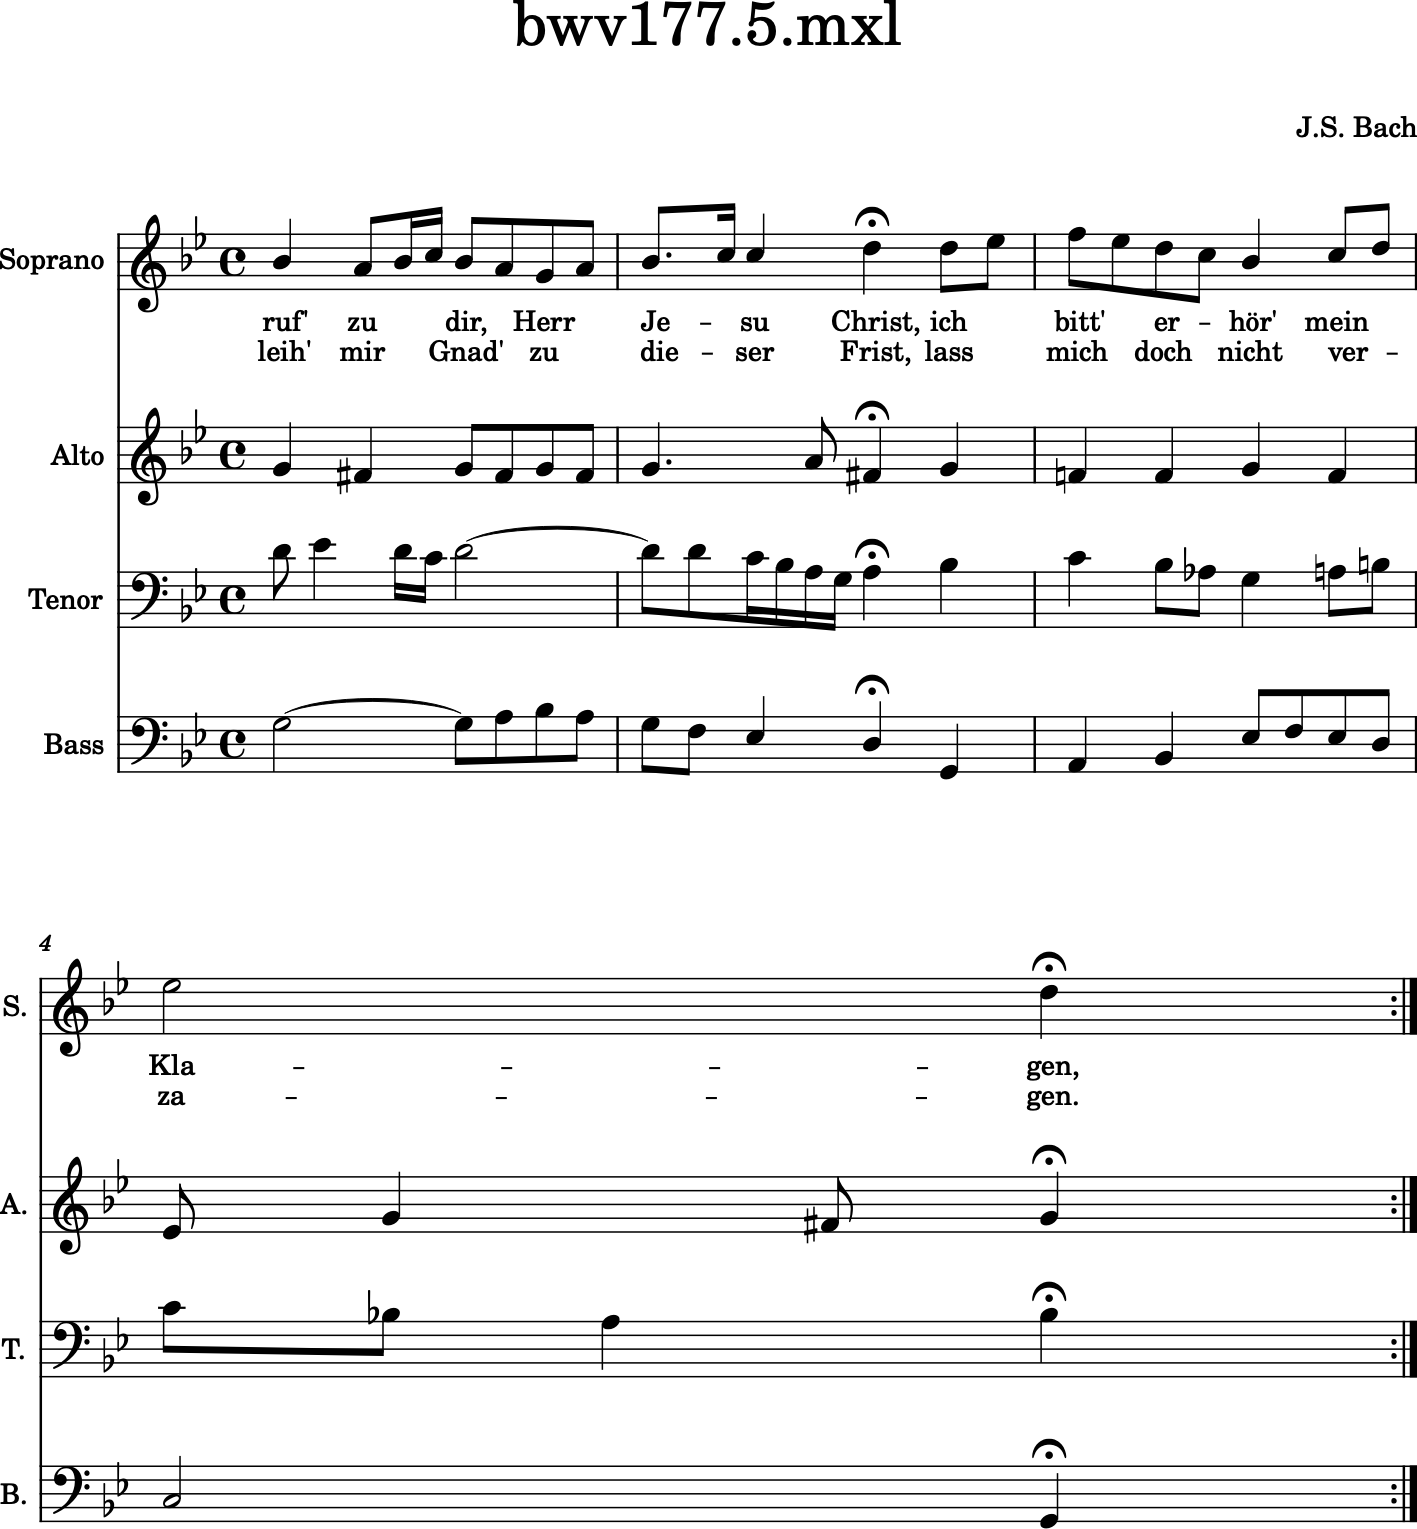

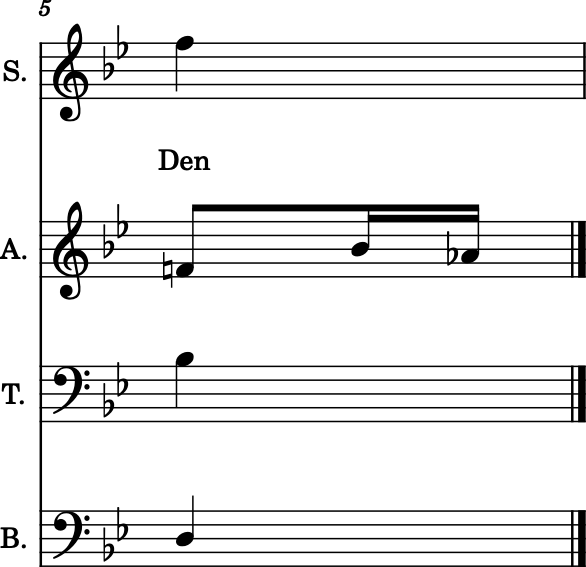

In [2]:
from music21 import *
score = corpus.parse('bach/bwv177.5')
score.measures(1, 4).show()

## One voice per part — first, the boring-but-essential step

The voice-leading tools compare *parts*: they line up what part A is doing
against what part B is doing and ask how each pair of voices moves. That only
works if **each part holds a single melodic line**.

A Bach chorale from the corpus already does — Soprano, Alto, Tenor, and Bass are
four separate `Part` objects. But lots of real scores don't: an SATB hymn is
often engraved on two staves with *two voices per staff* (S+A up top, T+B on the
bottom). Feed that to the analyzer as-is and it has no idea which note belongs to
which line.

The one-liner that fixes this for *both* cases is
:meth:`~music21.stream.base.Score.voicesToParts`. It promotes every voice to its
own part, and it's a harmless no-op when the parts are already single lines — so
we can run it unconditionally and stop worrying.

In [3]:
parts = score.voicesToParts()
len(parts.parts)  # four single-line parts, S A T B

4

## Slicing the score into simultaneities

To compare voices moment by moment, we turn the score into a tree of overlapping
note-spans with :func:`~music21.tree.fromStream.asTimespans`. Walking that tree
gives us **verticalities** — the chord-like vertical slices of the music, one
for every place where some voice changes note.

In [4]:
scoreTree = tree.fromStream.asTimespans(parts, flatten=True, classList=(note.Note,))
scoreTree.getVerticalityAt(8.0)

<music21.tree.verticality.Verticality 8.0 {G2 B-3 G4 D5}>

Each verticality knows how to look one slice backward and hand us a
:class:`~music21.voiceLeading.VoiceLeadingQuartet` for every pair of voices —
the two notes voice 1 moved *from* and *to*, and the same for voice 2. And a
quartet can classify its own motion. The two methods we care about today:

* `parallelFifth()` — the voices stay a perfect fifth apart, both moving.
* `parallelOctave()` — same idea, a perfect octave (or unison) apart.

(There are more in the class — `parallelUnison()`, `hiddenFifth()`,
`hiddenOctave()`, `motionType()` — worth a browse when you want to widen the
net.) Let's look at the quartets at one ordinary verticality just to see the
shape of the thing:

In [5]:
for vlq in scoreTree.getVerticalityAt(8.0).getAllVoiceLeadingQuartets(includeRests=False):
    print(vlq.v1n1.nameWithOctave, '->', vlq.v1n2.nameWithOctave, '  with  ',
          vlq.v2n1.nameWithOctave, '->', vlq.v2n2.nameWithOctave,
          '  parallel 5th?', vlq.parallelFifth())

D5 -> D5   with   F#4 -> G4   parallel 5th? False
D5 -> D5   with   A3 -> B-3   parallel 5th? False
D5 -> D5   with   D3 -> G2   parallel 5th? False
F#4 -> G4   with   A3 -> B-3   parallel 5th? False
F#4 -> G4   with   D3 -> G2   parallel 5th? False
A3 -> B-3   with   D3 -> G2   parallel 5th? False


Nothing parallel there — good, that's the expected answer almost
everywhere. Now let's stop sampling and sweep the *whole* chorale. We walk every
verticality, ask every quartet whether it's a parallel fifth or octave, and
print the survivors. (We de-duplicate because a sustained note makes the same
quartet reappear under several consecutive verticalities.)

In [6]:
seen = set()
for vert in scoreTree.iterateVerticalities():
    for vlq in vert.getAllVoiceLeadingQuartets(includeRests=False):
        if vlq.parallelFifth():
            kind = 'parallel 5th'
        elif vlq.parallelOctave():
            kind = 'parallel 8ve'
        else:
            continue
        m = vlq.v1n1.measureNumber
        key = (m, vlq.v1n1.nameWithOctave, vlq.v2n1.nameWithOctave)
        if key in seen:
            continue
        seen.add(key)
        print(f'm{m}: {kind}  '
              f'{vlq.v1n1.nameWithOctave}->{vlq.v1n2.nameWithOctave}  with  '
              f'{vlq.v2n1.nameWithOctave}->{vlq.v2n2.nameWithOctave}')

m11: parallel 5th  C5->D5  with  F4->G4


Well, well. One hit — a parallel fifth in **measure 11**, between the
notes `C5->D5` and `F4->G4`. The upper pair are the **Soprano and Alto**. So
much for *never*.

Let's zoom in on exactly the moment it happens. The motion lands on the
verticality at offset 43.0, so we'll list every quartet there and let the flag
point at the culprit:

In [7]:
for vlq in scoreTree.getVerticalityAt(43.0).getAllVoiceLeadingQuartets(includeRests=False):
    flag = '  <== PARALLEL FIFTH' if vlq.parallelFifth() else ''
    print(vlq.v1n1.nameWithOctave, '->', vlq.v1n2.nameWithOctave, '  with  ',
          vlq.v2n1.nameWithOctave, '->', vlq.v2n2.nameWithOctave, flag)

C5 -> D5   with   F4 -> G4   <== PARALLEL FIFTH
C5 -> D5   with   C4 -> B3 
C5 -> D5   with   A-2 -> G2 
F4 -> G4   with   C4 -> B3 
F4 -> G4   with   A-2 -> G2 
C4 -> B3   with   A-2 -> G2 


And there it is in the score — let's look at measures 10–12:

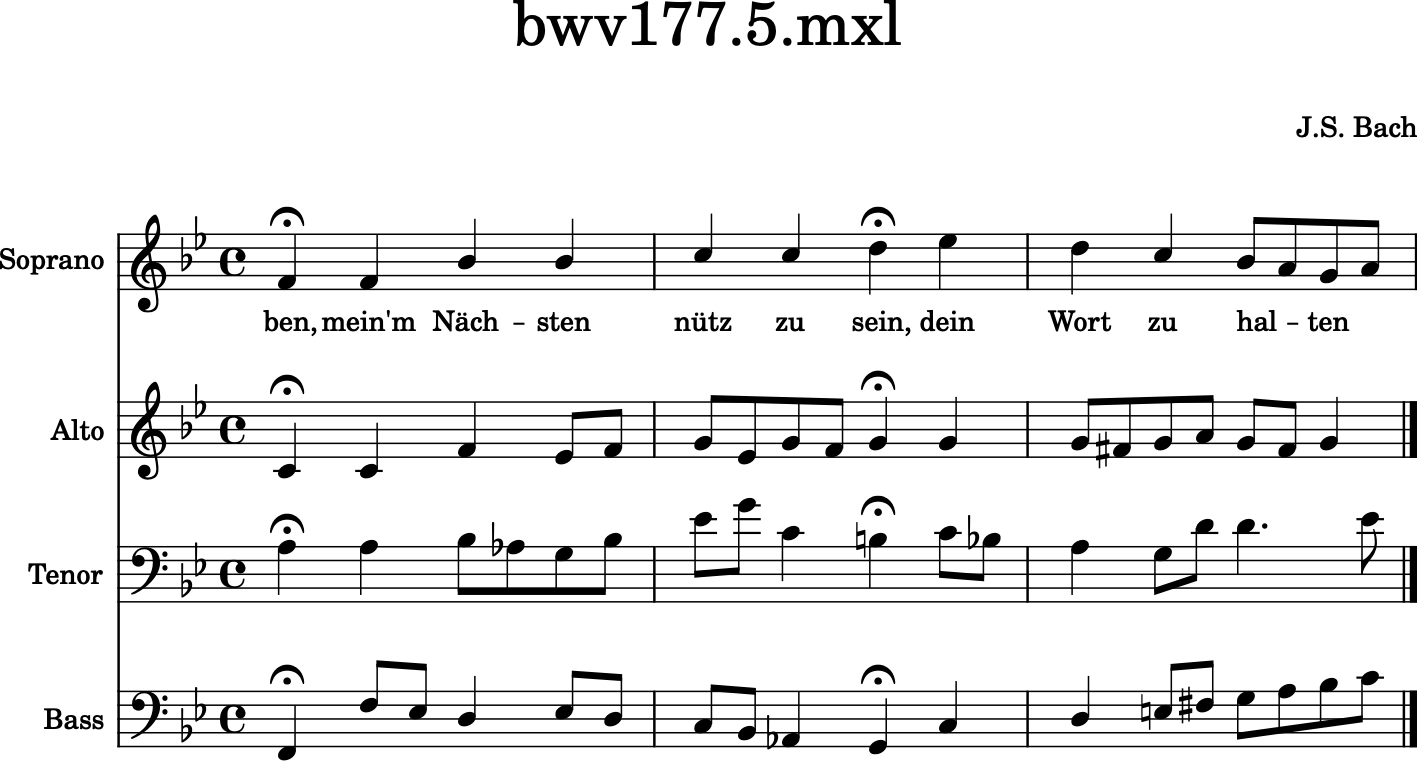

In [8]:
score.measures(10, 12).show()

### But is it a *real* one?

This is where the fun starts, because the computer found a fifth but a theory
teacher might shrug. Look at what the Alto is actually doing: it sits on G4,
dips down to **F4 as a lower-neighbor tone**, and comes right back to G4. The
Soprano, meanwhile, steps C5→D5. So the two perfect fifths (C5/F4, then D5/G4)
are real — but the first one lands on a passing ornament, not a structural beat.

This is exactly the sort of "fifth by a neighbor tone" that gets a paragraph of
its own in counterpoint textbooks and an argument in the seminar room. Our
detector, like any blunt instrument, reports the literal intervals and leaves
the judgment call to you — which is the right division of labor. The point of
the tool is to *find the candidates*; the point of the musician is to decide
which ones matter.

Let's package the sweep into a reusable function so we can aim it at anything:

In [9]:
def findParallels(score):
    '''Return (measureNumber, kind, VoiceLeadingQuartet) for every parallel
    perfect fifth or octave between any pair of voices in a score.'''
    parts = score.voicesToParts()  # one melodic line per part
    scoreTree = tree.fromStream.asTimespans(parts, flatten=True, classList=(note.Note,))
    seen = set()
    results = []
    for vert in scoreTree.iterateVerticalities():
        for vlq in vert.getAllVoiceLeadingQuartets(includeRests=False):
            if vlq.parallelFifth():
                kind = 'parallel 5th'
            elif vlq.parallelOctave():
                kind = 'parallel 8ve'
            else:
                continue
            m = vlq.v1n1.measureNumber
            key = (m, kind, vlq.v1n1.nameWithOctave, vlq.v2n1.nameWithOctave)
            if key in seen:
                continue
            seen.add(key)
            results.append((m, kind, vlq))
    return results


findParallels(score)

[(11,
  'parallel 5th',
  <music21.voiceLeading.VoiceLeadingQuartet v1n1=C5, v1n2=D5, v2n1=F4, v2n2=G4>)]

Now you have a one-call hunter. Point it at one of *your* files with
`findParallels(converter.parse('myChorale.musicxml'))`, or — in the spirit of
:ref:`Chapter 20 <usersGuide_20_examples2>` — turn it loose on the whole chorale
repertory and see which pieces have the most. (Spoiler: a fair number have one
or two ornamental fifths just like this; genuine structural ones are rare, which
is why the rule is a good one.)

A few honest caveats before you trust the output too far:

* It compares **every** pair of voices, so an intentional octave doubling — the
  bass under the melody on a final chord, say — shows up too. Eyeball each hit.
* `hiddenFifth()` and `hiddenOctave()` (perfect intervals *approached* by similar
  motion in the outer voices) are a separate, also-interesting question; swap
  them in to widen the search.
* Voices that cross or drop out can confuse the pairing. For plain homophonic
  chorale writing it's reliable.

## A second tool: open chords that never fill in their third

While we have the chorale open, here's a companion check for a different
weakness. A bare fifth or octave with no third is fine as a passing color — *if*
the third shows up over the same bass note before the harmony moves on. The thing
worth flagging is the open sonority that just sits there and then **leaves with
the bass while still thirdless**.

`chordify()` is perfect for this: it squashes all the parts into one running
stream of chords, a fresh chord at every change. For each chord, `chord.third`
is `None` when there's no third above the root. The plan: group consecutive
chords that share a bass pitch class, and flag a group that goes by without ever
sounding a third.

In [10]:
def findUnresolvedOpenChords(score):
    '''Return (measureNumber, chord) for open (thirdless) sonorities that never
    gain a third before the bass note changes.'''
    chordified = score.chordify()
    results = []
    group = []
    prevBass = None

    def flush(group):
        if not group or any(c.third is not None for c in group):
            return  # empty, or a third arrived over this bass -- fine
        openChords = [c for c in group
                      if c.third is None and len({p.name for p in c.pitches}) > 1]
        if not openChords:
            return
        c = openChords[0]
        meas = c.getContextByClass(stream.Measure)
        results.append((meas.number if meas is not None else None, c))

    for c in chordified.recurse().getElementsByClass('Chord'):
        bassName = c.bass().name
        if bassName != prevBass:
            flush(group)
            group = []
            prevBass = bassName
        group.append(c)
    flush(group)
    return results


findUnresolvedOpenChords(score)

[]

Empty — BWV 177.5 fills in every one of its thirds before moving on, just
as you'd hope. So that we can see the check actually bite, here's a tiny
hand-built progression that breaks the rule: an open fifth on D (D3–D4–A4, no F)
held while the bass stays on D, and then the bass jumps to G with the third
never having arrived.

In [11]:
openExample = stream.Score()
voices = [stream.Part() for _ in range(3)]
for row in [('A4', 'D4', 'D3'),   # open fifth on D, no third
            ('A4', 'D4', 'D3'),   # still open, bass unchanged
            ('B4', 'G4', 'G3')]:  # bass moves to G (now a full triad)
    for part, name in zip(voices, row):
        part.append(note.Note(name))
for part in voices:
    openExample.insert(0, part)

findUnresolvedOpenChords(openExample)

[(None, <music21.chord.Chord D3 D4 A4>)]

That D chord is correctly caught. The usual source of *false* alarms here
is the same ornament that made our Bach fifth debatable: a passing or neighbor
tone — in the bass or an upper voice — can briefly hide a third, or create a
bare fifth, for half a beat. If you want a stricter reading, reduce out the
non-chord tones first, or ignore any hit whose bass note lasts only a fraction
of a beat.

## Where to take it next

```python
score = converter.parse('myChorale.musicxml')
findParallels(score)
findUnresolvedOpenChords(score)
```

Both functions hand back plain lists, so you can feed the offending quartets and
chords straight into a `.show()` with the notes colored, tally them across a
folder of student exercises, or — the most fun — sweep the entire Bach chorale
corpus and build a little catalogue of every place the master let an ornamental
fifth slip through. The rule turns out to be *almost* always true, and the
exceptions are where the music gets interesting.